In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

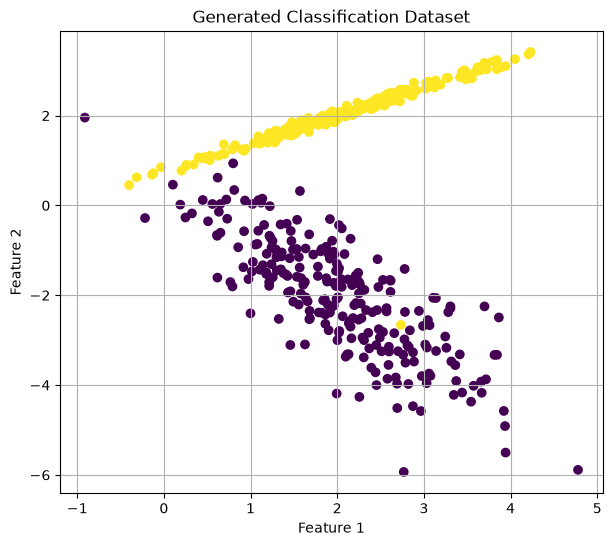

In [3]:
plt.figure(figsize=(7,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated Classification Dataset")
plt.grid()

plt.show()

In [4]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [6]:
weights = np.zeros(X_train.shape[1])

bias = 0

print(weights)
print(bias)

[0. 0.]
0


In [7]:
def sigmoid(z):

    return 1/(1+np.exp(-z))

In [8]:
print(sigmoid(-5))

print(sigmoid(0))

print(sigmoid(5))

0.0066928509242848554
0.5
0.9933071490757153


In [9]:
z = np.dot(X_train,weights)+bias

print(z[:5])

[0. 0. 0. 0. 0.]


In [10]:
prediction = sigmoid(z)

print(prediction[:5])

[0.5 0.5 0.5 0.5 0.5]


In [11]:
def loss_function(y_true,prediction):

    n = len(y_true)

    loss = -np.sum(

        y_true*np.log(prediction+1e-15)

        +

        (1-y_true)*np.log(1-prediction+1e-15)

    )/n

    return loss

In [12]:
loss = loss_function(

    y_train,

    prediction
)

print(loss)

0.6931471805599435


In [13]:
n = len(y_train)

dw = np.dot(

    X_train.T,

    (prediction-y_train)

)/n

db = np.sum(

    prediction-y_train

)/n

In [14]:
print(dw)

print(db)

[-0.00129205 -0.44592421]
-0.005


In [15]:
learning_rate = 0.1

In [16]:
weights = weights-learning_rate*dw

bias = bias-learning_rate*db

In [17]:
weights = np.zeros(X_train.shape[1])

bias = 0

learning_rate = 0.1

epochs = 1000

losses = []

In [18]:
for epoch in range(epochs):

    z = np.dot(X_train,weights)+bias

    prediction = sigmoid(z)

    loss = loss_function(

        y_train,

        prediction
    )

    losses.append(loss)

    dw = np.dot(

        X_train.T,

        (prediction-y_train)

    )/len(y_train)

    db = np.sum(

        prediction-y_train

    )/len(y_train)

    weights = weights-learning_rate*dw

    bias = bias-learning_rate*db

In [19]:
print("Weights")

print(weights)

print()

print("Bias")

print(bias)

Weights
[0.55620176 4.82604222]

Bias
-0.22206223584630355


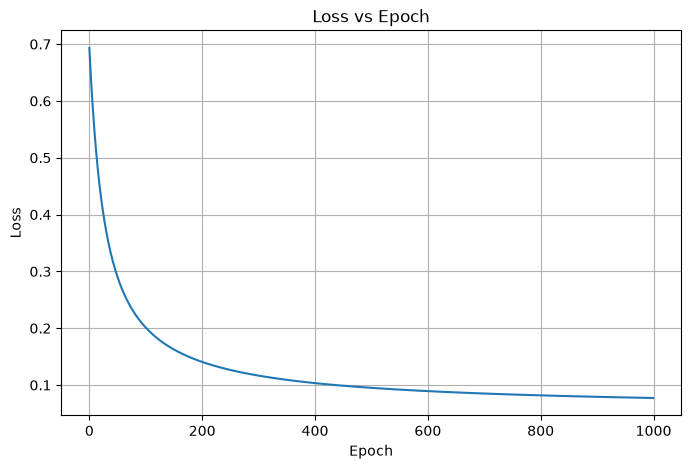

In [20]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.grid()

plt.show()

In [21]:
z = np.dot(X_test,weights)+bias

probability = sigmoid(z)

In [22]:
prediction = np.where(

    probability>=0.5,

    1,

    0
)

In [23]:
accuracy = accuracy_score(

    y_test,

    prediction
)

print("Accuracy =",accuracy)

Accuracy = 0.96


In [24]:
import pandas as pd

comparison = pd.DataFrame({

    "Actual":y_test,

    "Predicted":prediction,

    "Probability":probability

})

comparison.head(15)

,Actual,Predicted,Probability
0,1,1,0.890634
1,1,1,0.907189
2,0,0,0.005803
3,1,1,0.982849
4,0,0,0.000730
5,1,0,0.475161
6,0,0,0.045826
7,1,1,0.837362
8,0,0,0.349015
9,1,1,0.967525


In [25]:
sample = np.array([[1.5,0.2]])

sample = scaler.transform(sample)

z = np.dot(sample,weights)+bias

probability = sigmoid(z)

prediction = np.where(

    probability>=0.5,

    1,

    0
)

print("Probability :",probability)

print("Prediction :",prediction)

Probability : [0.45474138]
Prediction : [0]


In [27]:
sample = np.array([[1.5,0.2]])

sample = scaler.transform(sample)

z = np.dot(sample, weights) + bias

sample_probability = sigmoid(z)

sample_prediction = np.where(sample_probability >= 0.5, 1, 0)

print(sample_prediction)

[0]


In [28]:
from matplotlib.colors import ListedColormap

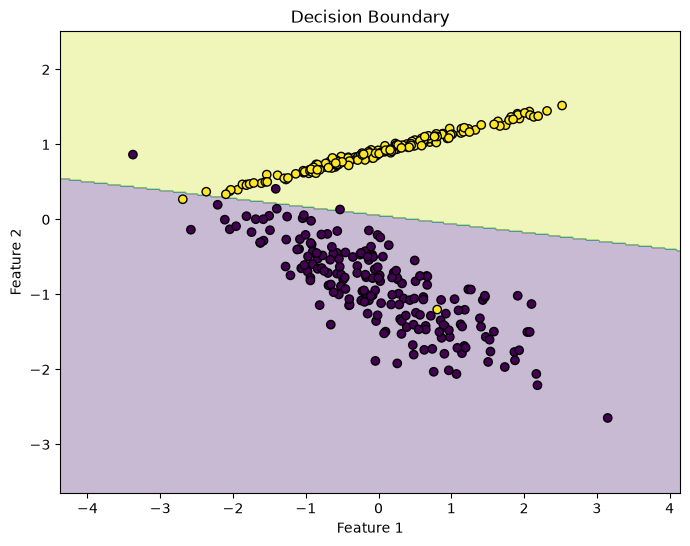

In [29]:
x1_min, x1_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
x2_min, x2_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, 0.02),
    np.arange(x2_min, x2_max, 0.02)
)

Z = model.predict(
    np.array([xx1.ravel(), xx2.ravel()]).T
)

Z = Z.reshape(xx1.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx1, xx2, Z, alpha=0.3)

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    edgecolor='k'
)

plt.title("Decision Boundary")

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.show()

In [30]:
from sklearn.metrics import roc_curve

In [31]:
y_prob = model.predict_proba(X_test)[:,1]

In [32]:
fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

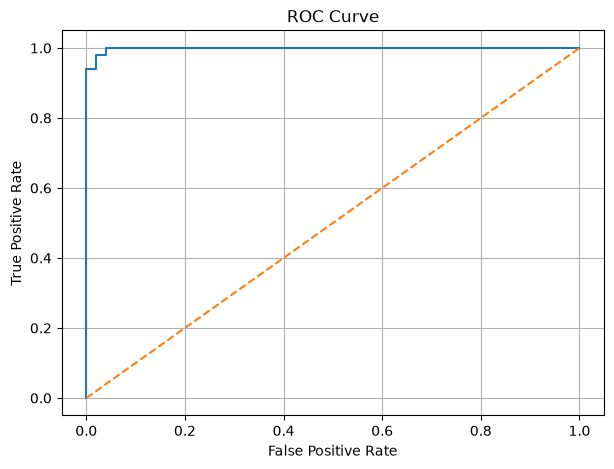

In [33]:
plt.figure(figsize=(7,5))

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.grid()

plt.show()

In [34]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_prob
)

print("AUC =",auc)

AUC = 0.9983993597438976


In [35]:
thresholds = [0.3,0.5,0.7]

for t in thresholds:

    prediction = (y_prob>=t).astype(int)

    acc = accuracy_score(
        y_test,
        prediction
    )

    print(
        "Threshold:",
        t,
        "Accuracy:",
        acc
    )

Threshold: 0.3 Accuracy: 0.97
Threshold: 0.5 Accuracy: 0.96
Threshold: 0.7 Accuracy: 0.97


In [36]:
model = LogisticRegression(

    penalty='l2',

    C=1,

    solver='lbfgs',

    max_iter=100,

    random_state=42
)

In [37]:
solvers = [

    'lbfgs',

    'liblinear',

    'newton-cg',

    'saga'
]

In [38]:
for s in solvers:

    model = LogisticRegression(

        solver=s,

        random_state=42,

        max_iter=500
    )

    model.fit(

        X_train,

        y_train
    )

    pred = model.predict(X_test)

    print(

        s,

        accuracy_score(

            y_test,

            pred
        )
    )

lbfgs 0.96
liblinear 0.96
newton-cg 0.96
saga 0.96


In [39]:
ridge = LogisticRegression(

    penalty='l2',

    solver='liblinear'
)

ridge.fit(X_train,y_train)

C:\Users\engrf\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, 

In [40]:
lasso = LogisticRegression(

    penalty='l1',

    solver='liblinear'
)

lasso.fit(X_train,y_train)

C:\Users\engrf\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\engrf\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, 

In [41]:
print("L2 Coefficients")

print(ridge.coef_)

print()

print("L1 Coefficients")

print(lasso.coef_)

L2 Coefficients
[[0.57569062 4.95329014]]

L1 Coefficients
[[0.93102633 6.75075777]]


In [42]:
ridge_pred = ridge.predict(X_test)

lasso_pred = lasso.predict(X_test)

print(
    "L2 Accuracy:",
    accuracy_score(
        y_test,
        ridge_pred
    )
)

print(
    "L1 Accuracy:",
    accuracy_score(
        y_test,
        lasso_pred
    )
)

L2 Accuracy: 0.96
L1 Accuracy: 0.96


In [43]:
import joblib

joblib.dump(

    model,

    "logistic_model.pkl"
)

['logistic_model.pkl']

In [46]:
loaded_model = joblib.load(

    "logistic_model.pkl"
)

In [47]:
loaded_model.predict(X_test[:5])

array([1, 1, 0, 1, 0])

In [50]:
# Scratch Logistic Regression Prediction

z = np.dot(X_test, weights) + bias

test_probability = sigmoid(z)

test_prediction = np.where(test_probability >= 0.5, 1, 0)

In [51]:
print(test_prediction[:10])

[1 1 0 1 0 0 0 1 0 1]


In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Scratch",
        "Sklearn",
        "L1 Logistic",
        "L2 Logistic"
    ],
    "Accuracy": [
        accuracy_score(y_test, test_prediction),
        accuracy_score(y_test, sk_pred),
        accuracy_score(y_test, lasso_pred),
        accuracy_score(y_test, ridge_pred)
    ]
})

comparison

,Model,Accuracy
0,Scratch,0.96
1,Sklearn,0.96
2,L1 Logistic,0.96
3,L2 Logistic,0.96


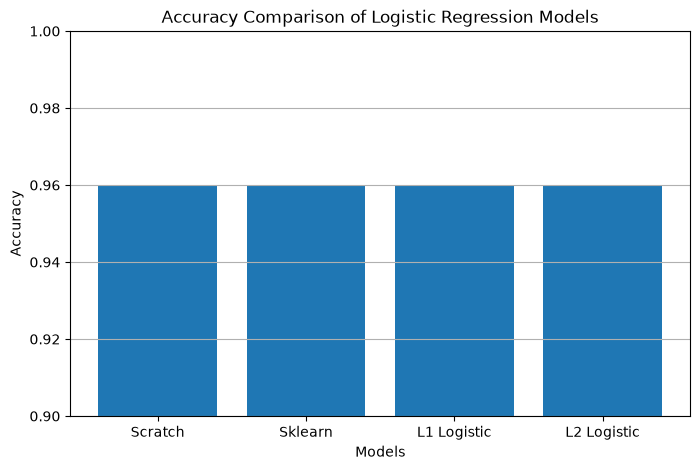

In [53]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Comparison of Logistic Regression Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.grid(axis="y")

plt.show()

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [56]:
comparison = pd.DataFrame({
    "Model": ["Scratch", "Sklearn", "L1", "L2"],
    "Accuracy": [
        accuracy_score(y_test, test_prediction),
        accuracy_score(y_test, sk_pred),
        accuracy_score(y_test, lasso_pred),
        accuracy_score(y_test, ridge_pred)
    ],
    "Precision": [
        precision_score(y_test, test_prediction),
        precision_score(y_test, sk_pred),
        precision_score(y_test, lasso_pred),
        precision_score(y_test, ridge_pred)
    ],
    "Recall": [
        recall_score(y_test, test_prediction),
        recall_score(y_test, sk_pred),
        recall_score(y_test, lasso_pred),
        recall_score(y_test, ridge_pred)
    ],
    "F1 Score": [
        f1_score(y_test, test_prediction),
        f1_score(y_test, sk_pred),
        f1_score(y_test, lasso_pred),
        f1_score(y_test, ridge_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Scratch,0.96,0.978723,0.938776,0.958333
1,Sklearn,0.96,0.978723,0.938776,0.958333
2,L1,0.96,0.978723,0.938776,0.958333
3,L2,0.96,0.978723,0.938776,0.958333


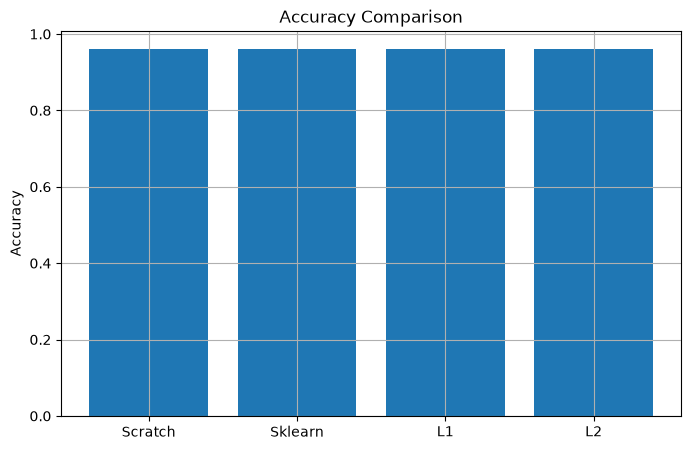

In [57]:
plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["Accuracy"]
)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.grid()

plt.show()